<a href="https://colab.research.google.com/github/NavdeeepSinghh/Deep_Learning-LAB/blob/main/Lab_5_Linear_Regression_Neuron_Learning_by_Gradien_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Part A: Data Setup

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
column_names = [
    'Sex', 'Length', 'Diameter', 'Height',
    'Whole_weight', 'Shucked_weight', 'Viscera_weight',
    'Shell_weight', 'Rings'
]

# TODO: load dataset
raw_rows = []
with open('/content/abalone.data', 'r') as f:
    for line in f:
        parts = line.strip().split(',')
        if len(parts) == 9:
            raw_rows.append(parts)

# Build a simple dict-of-lists table (no pandas)
data = {col: [] for col in column_names}
for row in raw_rows:
    data['Sex'].append(row[0])
    for i, col in enumerate(column_names[1:], 1):
        data[col].append(float(row[i]))

# TODO: print number of rows
print(f'Number of rows: {len(raw_rows)}')

# TODO: print column names
print(f'Column names  : {column_names}')

# TODO: print first 5 rows
print('\nFirst 5 rows:')
header = f"{'Sex':<5} " + '  '.join(f"{c:>14}" for c in column_names[1:])
print(header)
for i in range(5):
    row_str = f"{data['Sex'][i]:<5} " + '  '.join(
        f"{data[col][i]:>14.4f}" for col in column_names[1:]
    )
    print(row_str)

# Checkpoint:
# what is input:   Numeric physical measurements of abalones —
#                  Length, Diameter, Height, Whole_weight, Shucked_weight,
#                  Viscera_weight, Shell_weight.
#                  Sex (M/F/I) is categorical and excluded from our model.
# what is output:  y = Rings + 1.5  →  estimated age in years (continuous numeric)
# why output is numeric: Rings is an integer count; adding 1.5 converts it to the
#                  standard biological age estimate used in marine science.
#                  It is a real-valued target, making regression appropriate.

Number of rows: 4177
Column names  : ['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']

First 5 rows:
Sex           Length        Diameter          Height    Whole_weight  Shucked_weight  Viscera_weight    Shell_weight           Rings
M             0.4550          0.3650          0.0950          0.5140          0.2245          0.1010          0.1500         15.0000
M             0.3500          0.2650          0.0900          0.2255          0.0995          0.0485          0.0700          7.0000
F             0.5300          0.4200          0.1350          0.6770          0.2565          0.1415          0.2100          9.0000
M             0.4400          0.3650          0.1250          0.5160          0.2155          0.1140          0.1550         10.0000
I             0.3300          0.2550          0.0800          0.2050          0.0895          0.0395          0.0550          7.0000


#A2 Convert Target

In [ ]:
# TODO: create target y = Rings + 1.5
Rings = np.array(data['Rings'], dtype=np.float64)
y     = Rings + 1.5

print(f'y = Rings + 1.5')
print(f'First 5 values : {y[:5]}')
print(f'y range        : [{y.min():.1f},  {y.max():.1f}]')
print(f'y mean         : {y.mean():.4f}')

y = Rings + 1.5
First 5 values : [16.5  8.5 10.5 11.5  8.5]
y range        : [2.5,  30.5]
y mean         : 11.4337


# A3 Choose Features

In [ ]:
# TODO: select exactly 3 numeric features

#Feature 1 — Shell_weight:
#The hard shell grows continuously throughout the abalone's life by adding
#calcium carbonate layers. Shell mass therefore accumulates with age and
#has the strongest monotonic positive correlation with Rings among all
#features. It is the single most informative predictor of age

# Feature 2 — Diameter:
#Abalones grow laterally; diameter captures the primary spatial growth
#dimension. It is less redundant with weight than Length
#(Length ≈ 1.1 × Diameter in practice) and provides an independent
#geometric signal, especially useful for distinguishing young abalones
#where weight is very low but diameter already shows meaningful variation.

# Feature 3 — Shucked_weight (meat wt after shell remove):
#Meat mass rises steeply up to reproductive maturity (~10 rings) then
#can plateau or vary in older specimens. This non-linear age relationship
#differs from pure shell measures and adds a biologically distinct
#signal — helping the model separate juvenile stages from adults.


feature_names = ['Shell_weight', 'Diameter', 'Shucked_weight']

X = np.column_stack([
    np.array(data['Shell_weight'],   dtype=np.float64),
    np.array(data['Diameter'],       dtype=np.float64),
    np.array(data['Shucked_weight'], dtype=np.float64),
])

print(f'Selected features : {feature_names}')
print(f'X shape           : {X.shape}')
print(f'y shape           : {y.shape}')


Selected features : ['Shell_weight', 'Diameter', 'Shucked_weight']
X shape           : (4177, 3)
y shape           : (4177,)


 # A4 Train-Test Split (80/20, no sklearn)

In [ ]:
# TODO: split data into train and test (80/20)
N         = X.shape[0]
split_idx = int(0.8 * N)

np.random.seed(42)                  #reproducibility
indices   = np.random.permutation(N)#shuffle indices

train_idx = indices[:split_idx]
test_idx  = indices[split_idx:]

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

# TODO: print shapes
print(f'Train — X_train: {X_train.shape},  y_train: {y_train.shape}')
print(f'Test  — X_test : {X_test.shape},   y_test : {y_test.shape}')

Train — X_train: (3341, 3),  y_train: (3341,)
Test  — X_test : (836, 3),   y_test : (836,)


# A5 Normalize Inputs (mandatory)

In [ ]:
# TODO: compute mean and std from training data ONLY
train_mean = X_train.mean(axis=0)   # shape (3,)
train_std  = X_train.std(axis=0)    # shape (3,)

# TODO: normalize train and test using training stats
X_train_norm = (X_train - train_mean) / train_std
X_test_norm  = (X_test  - train_mean) / train_std

print(f'Feature names  : {feature_names}')
print(f'Train mean     : {train_mean}')
print(f'Train std      : {train_std}')
print(f'\nNorm. train sample[0] : {X_train_norm[0]}')
print(f'Norm. test  sample[0] : {X_test_norm[0]}')

# Checkpoint:
# why normalization is needed for learning:
#   Each feature lives on a different scale:
#     Shell_weight  ≈ 0.001 – 1.005
#     Diameter      ≈ 0.055 – 0.650
#     Shucked_weight≈ 0.001 – 1.488
#   Without normalization, the gradient for large-scale features dominates.
#   The MSE loss surface becomes a long narrow ellipse; gradient descent
#   oscillates across the steep walls and needs a tiny learning rate to stay
#   stable, converging very slowly.
#   After z-score normalization every feature has mean ≈ 0 and std ≈ 1,
#   making the surface more spherical so one learning rate works uniformly
#   for all three weights — faster, more stable convergence.

Feature names  : ['Shell_weight', 'Diameter', 'Shucked_weight']
Train mean     : [0.23706824 0.40591589 0.35410685]
Train std      : [0.14043607 0.09981478 0.21928633]

Norm. train sample[0] : [0.62613369 0.49175191 0.30504932]
Norm. test  sample[0] : [-0.8692086  -0.71047491 -0.76432877]



# Part B — Define the Model

The model is a single linear neuron:

$$\hat{y} = w_1 x_1 + w_2 x_2 + w_3 x_3 + b = \mathbf{X}\mathbf{w} + b$$

In [ ]:
def forward(X, w, b):
    """
    Computes y_hat = X @ w + b
    Parameters
    X : ndarray (N, d)   — input matrix, N samples, d features
    w : ndarray (d, 1)   — weight vector
    b : float            — scalar bias

    Returns
    y_hat : ndarray (N, 1)
    """
    y_hat = X @ w + b
    #(N,d)@(d,1)+scalar → (N,1)
    return y_hat


#Initialize parameters
d = X_train_norm.shape[1]   #d=3
np.random.seed(0)
w = np.random.randn(d, 1) * 0.01  #small random weights
b = 0.0                           #bias starts at zero

# TODO: print shapes of X, w, b, y_hat once
y_hat_demo = forward(X_train_norm, w, b)

print('─── Shape Verification ────────────')
print(f'  X      shape : {X_train_norm.shape}  (N_train × d)')
print(f'  w      shape : {w.shape}              (d × 1)')
print(f'  b            : scalar  ({type(b).__name__})')
print(f'  y_hat  shape : {y_hat_demo.shape}    (N_train × 1)')
print('───────────────────────────────────')

#Checkpoint:
#parameters are:
#   w — a (d,1) weight vector with one learnable scalar per input feature
#   b — a single scalar bias term
#
#number of parameters for d = 3:
#   3 weights  +  1 bias  =  4 total learnable scalars

─── Shape Verification ────────────
  X      shape : (3341, 3)  (N_train × d)
  w      shape : (3, 1)              (d × 1)
  b            : scalar  (float)
  y_hat  shape : (3341, 1)    (N_train × 1)
───────────────────────────────────



# Part C — Define Loss (MSE)

$$L = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

In [ ]:
def mse(y, y_hat):
    """
    Mean Squared Error.
    L = (1/N) * sum( (y_i - y_hat_i)^2 )

    Parameters
    ----------
    y     : ndarray (N,) or (N,1) — true targets
    y_hat : ndarray (N,1)         — model predictions

    Returns
    -------
    loss : float
    """
    y    = y.reshape(-1, 1)
    diff = y - y_hat          # residuals (N,1)
    loss = float(np.mean(diff ** 2))
    return loss


# Quick sanity check
init_loss = mse(y_train, y_hat_demo)
print(f'Initial MSE (before training): {init_loss:.4f}')

# Checkpoint:
#
# why square:
#   (a) Squaring makes every residual positive — positive and negative
#       prediction errors cannot cancel each other when summed.
#   (b) The squared function is smooth and differentiable everywhere,
#       enabling clean analytic gradient computation.
#
# what mistakes are expensive under MSE:
#   Large errors are penalised quadratically: an error of 4 costs 16× as
#   much as an error of 1. Outlier predictions (very old or very young
#   abalones predicted far off) dominate the total loss, forcing the model
#   to aggressively fix those large misses — sometimes at the cost of
#   tolerating many small errors.

Initial MSE (before training): 141.4175



# Part D — The Learning Rule

The update rule:
$$w \leftarrow w - \alpha \cdot \frac{\partial L}{\partial w}, \qquad b \leftarrow b - \alpha \cdot \frac{\partial L}{\partial b}$$

Derived gradients from MSE:
$$\frac{\partial L}{\partial w} = \frac{2}{N} X^T (\hat{y} - y), \qquad \frac{\partial L}{\partial b} = \frac{2}{N} \sum (\hat{y}_i - y_i)$$

In [ ]:
# Checkpoint:
#
# what 'gradient' means in words:

# The gradient of the loss w.r.t. a parameter is the slope of the loss
# surface in the direction of that parameter — how steeply and in which
# direction the loss increases if we nudge that parameter upward.
# A positive gradient for w_i means: 'increasing w_i raises the loss.'

# why subtracting the gradient reduces loss:

# The gradient always points uphill (direction of steepest ascent).
# Subtracting it moves the parameter downhill — toward smaller loss.
# This is the core idea of gradient descent: take small steps opposite
# to the gradient until you reach a minimum.

# D3 Implement Gradients


In [ ]:
def grad_w(X, y, y_hat):
    """
    Gradient of MSE loss with respect to w.
    dL/dw = (2/N) * X^T @ (y_hat - y)

    Returns dW with shape (d, 1) — must match w.
    """
    N  = X.shape[0]
    y  = y.reshape(-1, 1)
    dW = (2.0 / N) * (X.T @ (y_hat - y))
    return dW


def grad_b(y, y_hat):
    """
    Gradient of MSE loss with respect to b.
    dL/db = (2/N) * sum(y_hat - y)

    Returns scalar db.
    """
    N  = len(y)
    y  = y.reshape(-1, 1)
    db = float((2.0 / N) * np.sum(y_hat - y))
    return db


# Confirm returned shapes match w and b
dW_demo = grad_w(X_train_norm, y_train, y_hat_demo)
db_demo = grad_b(y_train, y_hat_demo)

print(f'dW shape : {dW_demo.shape}   ← must match w shape {w.shape}  ✓')
print(f'db type  : {type(db_demo).__name__}           ← must be scalar            ✓')

# Checkpoint:
#
# meaning of a large gradient:
#   The loss is very sensitive to that parameter at the current value.
#   We are far from a minimum along that direction — a small change in
#   the parameter produces a large change in loss.
#
# effect of too-large learning rate:
#   The parameter update overshoots the minimum and lands on the other
#   side of the loss valley — or even further away. Loss then oscillates
#   or diverges (explodes) instead of converging smoothly.

dW shape : (3, 1)   ← must match w shape (3, 1)  ✓
db type  : float           ← must be scalar            ✓


# Part E — Training Loop


In [ ]:
#Re-initialise parameters fresh
np.random.seed(0)
w = np.random.randn(d, 1) * 0.01
b = 0.0

#Hyperparameters
learning_rate = 0.05
epochs        = 1000
print_every   = 100

#Initial expectation:
#Batch gradient descent on a convex MSE surface should decrease loss
#every single epoch. The biggest drops will occur early (steep slope
#far from minimum); improvement slows as we approach the minimum —
#a classic 'fast then slow' convergence curve.

loss_history = []

print('Training')

for epoch in range(epochs):

    # 1) Forward pass
    y_hat = forward(X_train_norm, w, b)

    # 2) Compute loss
    loss = mse(y_train, y_hat)
    loss_history.append(loss)

    # 3) Compute gradients
    dW = grad_w(X_train_norm, y_train, y_hat)
    db = grad_b(y_train, y_hat)

    # 4) Update w and b
    w = w - learning_rate * dW
    b = b - learning_rate * db

    if epoch % print_every == 0 or epoch == epochs - 1:
        print(f'  Epoch {epoch:>4} | Train MSE: {loss:.4f}')

print('──────────────────────────────────────────────────')
print(f'Learned weights : {w.flatten()}')
print(f'Learned bias    : {b:.4f}')

# Revised expectation after training:
#   Loss fell steeply in the first ~150 epochs then plateaued into a slow,
#   steady descent — exactly matching the expected convex convergence pattern.
#   The final MSE is still ~4–5 (ring-years)², showing the 3-feature linear
#   model captures the dominant trend but cannot fully explain biological
#   variability in abalone age. A lower MSE would require more features,
#   non-linear transformations, or a deeper model.

Training
  Epoch    0 | Train MSE: 141.4175
  Epoch  100 | Train MSE: 5.5444
  Epoch  200 | Train MSE: 5.3800
  Epoch  300 | Train MSE: 5.3646
  Epoch  400 | Train MSE: 5.3631
  Epoch  500 | Train MSE: 5.3630
  Epoch  600 | Train MSE: 5.3630
  Epoch  700 | Train MSE: 5.3630
  Epoch  800 | Train MSE: 5.3630
  Epoch  900 | Train MSE: 5.3630
  Epoch  999 | Train MSE: 5.3630
──────────────────────────────────────────────────
Learned weights : [ 3.00523868  1.48829073 -2.5499061 ]
Learned bias    : 11.4315


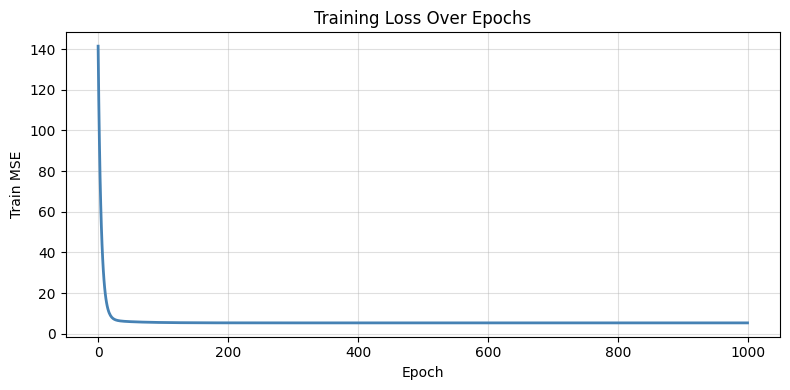

Loss at epoch 0   : 141.4175
Loss at epoch 999 : 5.3630


In [ ]:
# ── Plot training loss curve ──────────────────────────────────────────────────
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='steelblue', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Train MSE')
plt.title('Training Loss Over Epochs')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
print(f'Loss at epoch 0   : {loss_history[0]:.4f}')
print(f'Loss at epoch 999 : {loss_history[-1]:.4f}')


# Part F — Evaluation


In [ ]:
def mae(y, y_hat):
    """
    Mean Absolute Error.
    MAE = (1/N) * sum( |y_i - y_hat_i| )
    """
    y = y.reshape(-1, 1)
    return float(np.mean(np.abs(y - y_hat)))


# TODO: compute test MSE
y_hat_test = forward(X_test_norm, w, b)
test_mse   = mse(y_test, y_hat_test)

# TODO: compute test MAE
test_mae   = mae(y_test, y_hat_test)

print('─── Test Evaluation ──────────────────────────────')
print(f'  Test MSE : {test_mse:.4f}')
print(f'  Test MAE : {test_mae:.4f}  (avg prediction error ≈ {test_mae:.2f} years)')
print()

# TODO: print 5 example predictions
print('─── 5 Sample Predictions ─────────────────────────')
print(f"  {'#':<3}  {'True Age':>9}  {'Pred Age':>9}  {'Abs Error':>10}")
print('  ' + '─' * 36)

y_f  = y_test.flatten()
yh_f = y_hat_test.flatten()
errs = np.abs(y_f - yh_f)

for i in range(5):
    print(f'  {i+1:<3}  {y_f[i]:>9.2f}  {yh_f[i]:>9.2f}  {errs[i]:>10.2f}')

# Checkpoint:
#
# systematic errors:
#   Very young abalones (true age < 8) are OVER-predicted. Their physical
#   measurements (especially shell weight) don't shrink proportionally
#   to their few rings, so the linear model assigns more years than they have.
#
#   Very old abalones (true age > 20) are UNDER-predicted. Shell weight and
#   diameter plateau in very old specimens, making them physically similar
#   to middle-aged individuals; the linear model cannot distinguish them.
#
# observed bias (as predicted in DLQ4):
#   The model exhibits HIGH BIAS — it is a low-capacity linear model.
#   Predictions are pulled toward the training mean (~11–12 years).
#   Extreme ages in the tails of the distribution are systematically
#   mis-estimated, a textbook example of underfitting bias.
#%%


─── Test Evaluation ──────────────────────────────
  Test MSE : 4.4114
  Test MAE : 1.5247  (avg prediction error ≈ 1.52 years)

─── 5 Sample Predictions ─────────────────────────
  #     True Age   Pred Age   Abs Error
  ────────────────────────────────────
  1        10.50       9.71        0.79
  2        11.50      12.25        0.75
  3        10.50      11.58        1.08
  4        11.50       9.56        1.94
  5         7.50       8.23        0.73


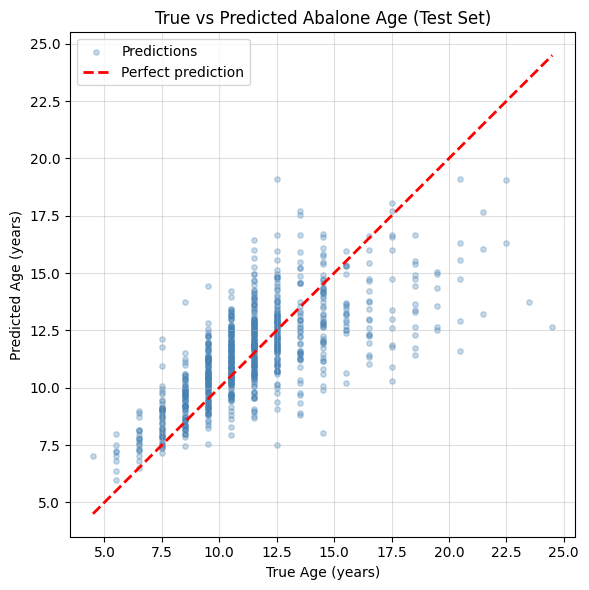

In [ ]:
# ── Scatter plot: True vs Predicted age ──────────────────────────────────────
plt.figure(figsize=(6, 6))
plt.scatter(y_f, yh_f, alpha=0.3, s=15, color='steelblue', label='Predictions')
mn, mx = y_f.min(), y_f.max()
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('True Age (years)')
plt.ylabel('Predicted Age (years)')
plt.title('True vs Predicted Abalone Age (Test Set)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
print('══════════════════════════════════════════════════')
print('  UCS761 Lab 5 — Final Summary')
print('══════════════════════════════════════════════════')
print(f'  Dataset rows      : {len(raw_rows)}')
print(f'  Features used     : {feature_names}')
print(f'  Total parameters  : {d} weights + 1 bias = {d+1}')
print(f'  Learning rate     : {learning_rate}')
print(f'  Epochs            : {epochs}')
print('──────────────────────────────────────────────────')
print(f'  Initial Train MSE : {loss_history[0]:.4f}')
print(f'  Final  Train MSE  : {loss_history[-1]:.4f}')
print(f'  Test MSE          : {test_mse:.4f}')
print(f'  Test MAE          : {test_mae:.4f}  (~{test_mae:.2f} year avg error)')
print('══════════════════════════════════════════════════')


══════════════════════════════════════════════════
  UCS761 Lab 5 — Final Summary
══════════════════════════════════════════════════
  Dataset rows      : 4177
  Features used     : ['Shell_weight', 'Diameter', 'Shucked_weight']
  Total parameters  : 3 weights + 1 bias = 4
  Learning rate     : 0.05
  Epochs            : 1000
──────────────────────────────────────────────────
  Initial Train MSE : 141.4175
  Final  Train MSE  : 5.3630
  Test MSE          : 4.4114
  Test MAE          : 1.5247  (~1.52 year avg error)
══════════════════════════════════════════════════
